<a href="https://colab.research.google.com/github/Maartzzz/Modelado-Platano/blob/main/pipeColorimetria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del Dataset

In [ ]:
# ============================================================
# BLOQUE 1
# PREPARACIÓN DEL DATASET
# ============================================================

!pip install pillow-heif -q

import os
import re
import shutil
import zipfile

from PIL import Image
from pillow_heif import register_heif_opener

register_heif_opener()

In [ ]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

ZIP_NAME = "PS-imagenes.zip"

WORK_DIR = "/content"

RAW_FOLDER = os.path.join(
    WORK_DIR,
    "imagenes_originales"
)

PNG_FOLDER = os.path.join(
    WORK_DIR,
    "imagenes_png"
)

os.makedirs(
    RAW_FOLDER,
    exist_ok=True
)

os.makedirs(
    PNG_FOLDER,
    exist_ok=True
)

In [ ]:
# ============================================================
# DESCOMPRIMIR
# ============================================================

with zipfile.ZipFile(ZIP_NAME,"r") as zip_ref:

    zip_ref.extractall(RAW_FOLDER)

print("Descompresión completada")

Descompresión completada


In [ ]:
# ============================================================
# BUSCAR IMÁGENES
# ============================================================

SUPPORTED = (

    ".heic",
    ".HEIC",

    ".jpg",
    ".JPG",

    ".jpeg",
    ".JPEG",

    ".png",
    ".PNG"

)

image_files=[]

for root,dirs,files in os.walk(RAW_FOLDER):

    for file in files:

        if file.endswith(SUPPORTED):

            image_files.append(

                os.path.join(root,file)

            )

print("Total imágenes encontradas:",len(image_files))

Total imágenes encontradas: 189


In [ ]:
# ============================================================
# CONVERSIÓN A PNG
# ============================================================

converted=[]

for img_path in image_files:

    filename=os.path.splitext(

        os.path.basename(img_path)

    )[0]

    output=os.path.join(

        PNG_FOLDER,

        filename+".png"

    )

    try:

        img=Image.open(img_path)

        img.save(

            output,

            format="PNG"

        )

        converted.append(output)

    except Exception as e:

        print(

            "Error:",img_path

        )

        print(e)

print("PNG generados:",len(converted))

PNG generados: 189


In [ ]:
# ============================================================
# VALIDACIÓN DE NOMBRES
# ============================================================

pattern = r"PS-(\d{1,2})([ABC])\.png"

valid=[]

invalid=[]

for img in converted:

    name=os.path.basename(img)

    if re.match(pattern,name):

        valid.append(name)

    else:

        invalid.append(name)

print("Imágenes válidas:",len(valid))

print("Imágenes inválidas:",len(invalid))

if len(invalid)>0:

    print()

    print("Archivos con nombre incorrecto")

    for i in invalid:

        print(i)

Imágenes válidas: 189
Imágenes inválidas: 0


In [ ]:
# ============================================================
# VALIDAR MUESTRAS
# ============================================================

dataset={}

for file in valid:

    match=re.match(

        pattern,

        file

    )

    sample=int(match.group(1))

    side=match.group(2)

    if sample not in dataset:

        dataset[sample]=[]

    dataset[sample].append(side)

print("="*60)

print("Número de muestras:",len(dataset))

print("="*60)

missing=[]

for sample in sorted(dataset.keys()):

    sides=set(dataset[sample])

    expected={"A","B","C"}

    if sides!=expected:

        missing.append(sample)

if len(missing)==0:

    print("Todas las muestras poseen A-B-C")

else:

    print("Muestras incompletas")

    print(missing)

Número de muestras: 63
Todas las muestras poseen A-B-C


In [ ]:
# ============================================================
# RESUMEN
# ============================================================

print("="*60)

print("Imágenes originales:",len(image_files))

print("PNG generados:",len(converted))

print("Muestras:",len(dataset))

print("Imágenes esperadas:",63*3)

print("="*60)

Imágenes originales: 189
PNG generados: 189
Muestras: 63
Imágenes esperadas: 189


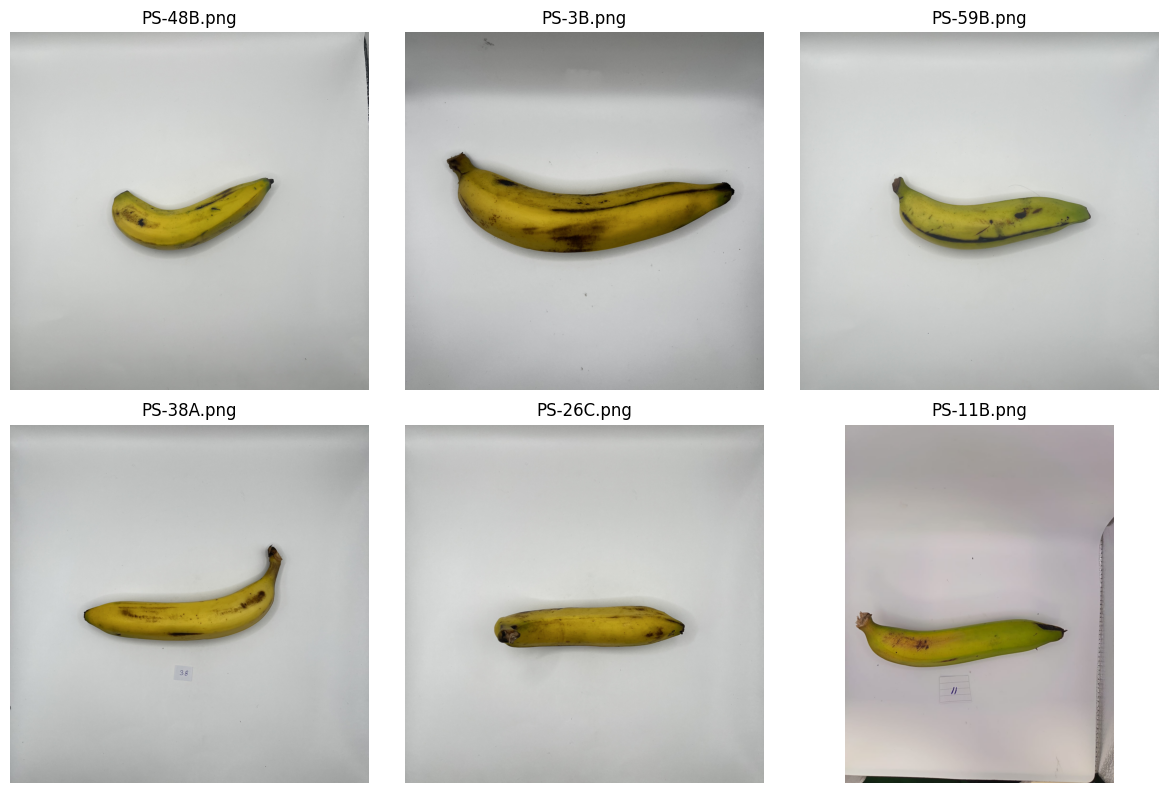

In [ ]:
import random
import matplotlib.pyplot as plt

fig,axes=plt.subplots(2,3,figsize=(12,8))

for ax in axes.flatten():

    img_path=random.choice(converted)

    img=Image.open(img_path)

    ax.imshow(img)

    ax.set_title(

        os.path.basename(img_path)

    )

    ax.axis("off")

plt.tight_layout()

plt.show()

# Control de Calidad

In [ ]:
# ============================================================
# BLOQUE 2
# CONTROL DE CALIDAD
# ============================================================

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

In [ ]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

quality_data = []

for img_path in tqdm(converted):

    img = cv2.imread(img_path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    height, width = img_rgb.shape[:2]

    quality_data.append({

        "Image": os.path.basename(img_path),

        "Width": width,

        "Height": height,

        "Channels": img_rgb.shape[2]

    })

quality_df = pd.DataFrame(quality_data)

quality_df.head()

100%|██████████| 189/189 [00:52<00:00,  3.63it/s]


,Image,Width,Height,Channels
0,PS-18A.png,3024,3024,3
1,PS-22C.png,3024,3024,3
2,PS-63B.png,3024,3024,3
3,PS-48B.png,3024,3024,3
4,PS-55C.png,3024,3024,3


In [ ]:
quality_df[
    ["Width","Height"]
].value_counts()

,,count
Width,Height,
3024,3024,171
1125,1500,18


In [ ]:
quality_df.describe()

,Width,Height,Channels,BlurScore
count,189.000000,189.000000,189.0,189.000000
mean,2843.142857,2878.857143,3.0,226.534803
std,558.919737,448.548541,0.0,74.926259
min,1125.000000,1500.000000,3.0,64.158141
25%,3024.000000,3024.000000,3.0,193.345716
50%,3024.000000,3024.000000,3.0,229.204651
75%,3024.000000,3024.000000,3.0,270.799993
max,3024.000000,3024.000000,3.0,393.600415


In [ ]:
# ============================================================
# DETECCIÓN DE BLUR
# ============================================================

blur_scores = []

for img_path in tqdm(converted):

    gray = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    blur_scores.append(score)

quality_df["BlurScore"] = blur_scores

100%|██████████| 189/189 [01:04<00:00,  2.94it/s]


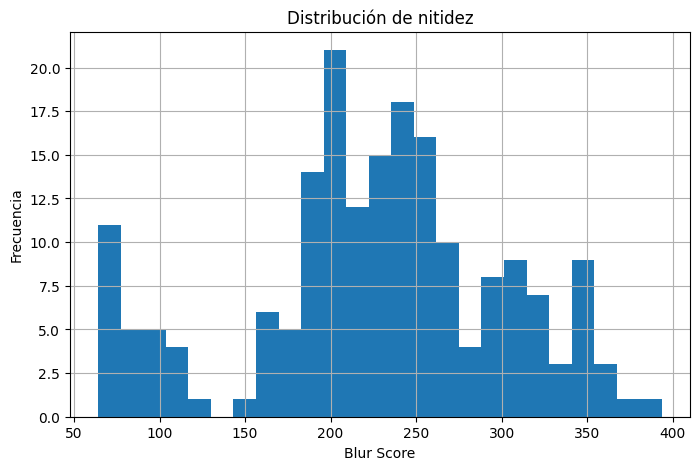

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    quality_df["BlurScore"],
    bins=25
)

plt.xlabel("Blur Score")

plt.ylabel("Frecuencia")

plt.title("Distribución de nitidez")

plt.grid()

plt.show()

In [ ]:
quality_df.sort_values(

    by="BlurScore"

).head(10)

,Image,Width,Height,Channels,BlurScore
140,PS-9A.png,1125,1500,3,64.158141
109,PS-10B.png,1125,1500,3,65.297334
128,PS-11A.png,1125,1500,3,67.880577
53,PS-10C.png,1125,1500,3,69.952942
129,PS-12B.png,1125,1500,3,70.035868
16,PS-9C.png,1125,1500,3,72.799473
31,PS-11C.png,1125,1500,3,73.273564
164,PS-12A.png,1125,1500,3,74.627917
73,PS-11B.png,1125,1500,3,75.576185
151,PS-9B.png,1125,1500,3,76.389966


In [ ]:
brightness = []

for img_path in tqdm(converted):

    img = cv2.imread(img_path)

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    value = hsv[:,:,2]

    brightness.append(

        value.mean()

    )

quality_df["Brightness"] = brightness

100%|██████████| 189/189 [01:01<00:00,  3.08it/s]


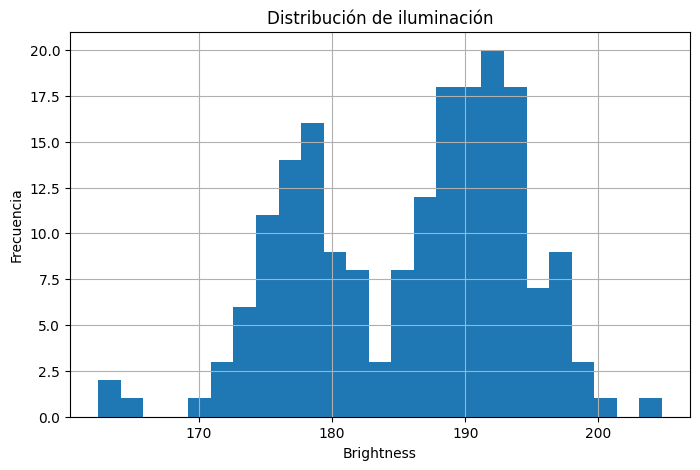

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(

    quality_df["Brightness"],

    bins=25

)

plt.xlabel("Brightness")

plt.ylabel("Frecuencia")

plt.title("Distribución de iluminación")

plt.grid()

plt.show()

In [ ]:
print("Más oscuras")

display(

    quality_df.sort_values(

        by="Brightness"

    ).head()

)

print()

print("Más brillantes")

display(

    quality_df.sort_values(

        by="Brightness",

        ascending=False

    ).head()

)

Más oscuras


,Image,Width,Height,Channels,BlurScore,Brightness
1,PS-22C.png,3024,3024,3,348.256371,162.445068
44,PS-7A.png,1125,1500,3,84.518681,163.844330
83,PS-16C.png,3024,3024,3,346.469693,164.202885
31,PS-11C.png,1125,1500,3,73.273564,170.707299
178,PS-8C.png,1125,1500,3,85.966325,171.261861



Más brillantes


,Image,Width,Height,Channels,BlurScore,Brightness
22,PS-38B.png,3024,3024,3,164.385057,204.765648
130,PS-49A.png,3024,3024,3,233.378321,199.939413
126,PS-34C.png,3024,3024,3,107.689723,198.718781
2,PS-63B.png,3024,3024,3,116.582884,198.622490
180,PS-26B.png,3024,3024,3,200.882075,198.608851


In [ ]:
print("="*60)

print("RESUMEN DEL CONTROL DE CALIDAD")

print("="*60)

print()

print("Número de imágenes :", len(quality_df))

print()

print("Resolución más frecuente")

print(

    quality_df[
        ["Width","Height"]
    ].mode()

)

print()

print(

    f"Blur medio : {quality_df['BlurScore'].mean():.2f}"

)

print(

    f"Blur mínimo : {quality_df['BlurScore'].min():.2f}"

)

print(

    f"Blur máximo : {quality_df['BlurScore'].max():.2f}"

)

print()

print(

    f"Brillo medio : {quality_df['Brightness'].mean():.2f}"

)

print("="*60)

RESUMEN DEL CONTROL DE CALIDAD

Número de imágenes : 189

Resolución más frecuente
   Width  Height
0   3024    3024

Blur medio : 226.53
Blur mínimo : 64.16
Blur máximo : 393.60

Brillo medio : 185.84


# Segmentación

In [ ]:
!pip install rembg
!pip install onnxruntime

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from rembg import remove

In [ ]:
def segment_banana(image_rgb):
    """
    Segmentación usando U²-Net (rembg).

    Devuelve:
        mask
        crop
        rgba
    """

    # rembg trabaja mejor con PNG en memoria
    success, buffer = cv2.imencode(".png",
                                   cv2.cvtColor(image_rgb,
                                                cv2.COLOR_RGB2BGR))

    output = remove(buffer.tobytes())

    output = cv2.imdecode(
        np.frombuffer(output, np.uint8),
        cv2.IMREAD_UNCHANGED
    )

    rgba = cv2.cvtColor(
        output,
        cv2.COLOR_BGRA2RGBA
    )

    alpha = rgba[:,:,3]

    mask = np.where(alpha>20,255,0).astype(np.uint8)

    # eliminar ruido

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (7,7)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Bounding Box

    coords = cv2.findNonZero(mask)

    if coords is None:

        return None,None,None

    x,y,w,h = cv2.boundingRect(coords)

    padding=25

    x=max(0,x-padding)

    y=max(0,y-padding)

    x2=min(mask.shape[1],x+w+2*padding)

    y2=min(mask.shape[0],y+h+2*padding)

    crop = rgba[
        y:y2,
        x:x2
    ]

    return mask,crop,rgba

In [ ]:
sample=random.choice(converted)

img=cv2.imread(sample)

img=cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

mask,crop,rgba=segment_banana(img)

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

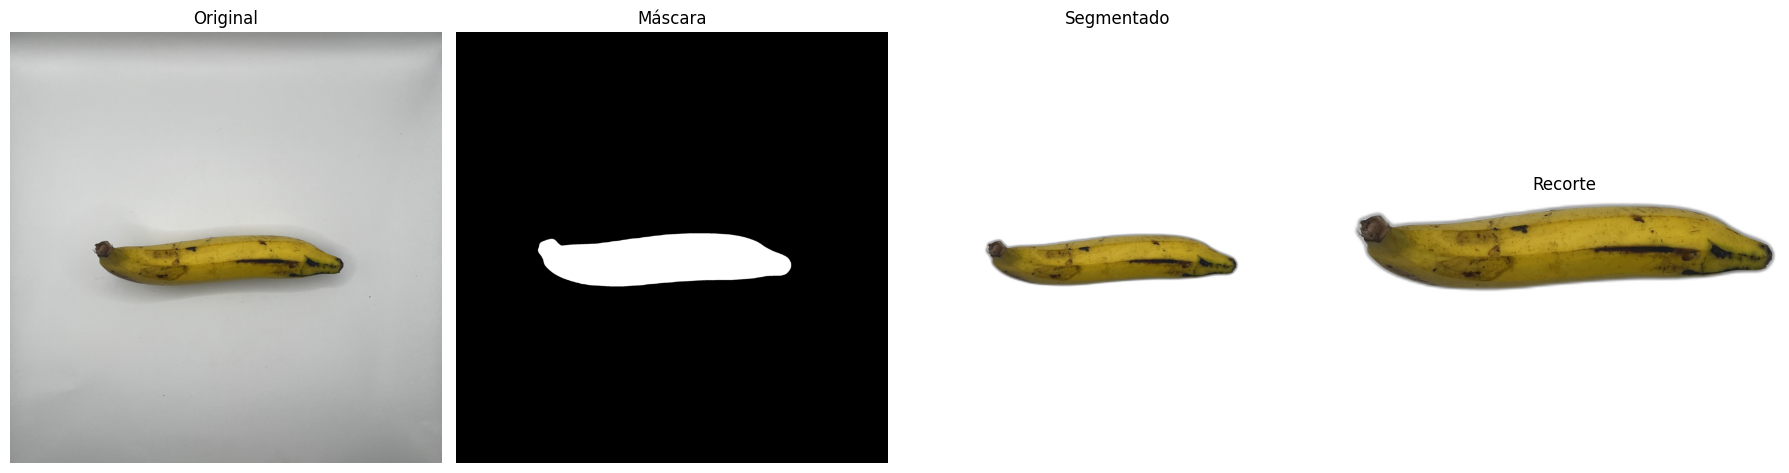

In [ ]:
fig,ax=plt.subplots(
    1,
    4,
    figsize=(18,6)
)

ax[0].imshow(img)
ax[0].set_title("Original")

ax[1].imshow(mask,cmap="gray")
ax[1].set_title("Máscara")

ax[2].imshow(rgba)
ax[2].set_title("Segmentado")

ax[3].imshow(crop)
ax[3].set_title("Recorte")

for a in ax:
    a.axis("off")

plt.tight_layout()

plt.show()

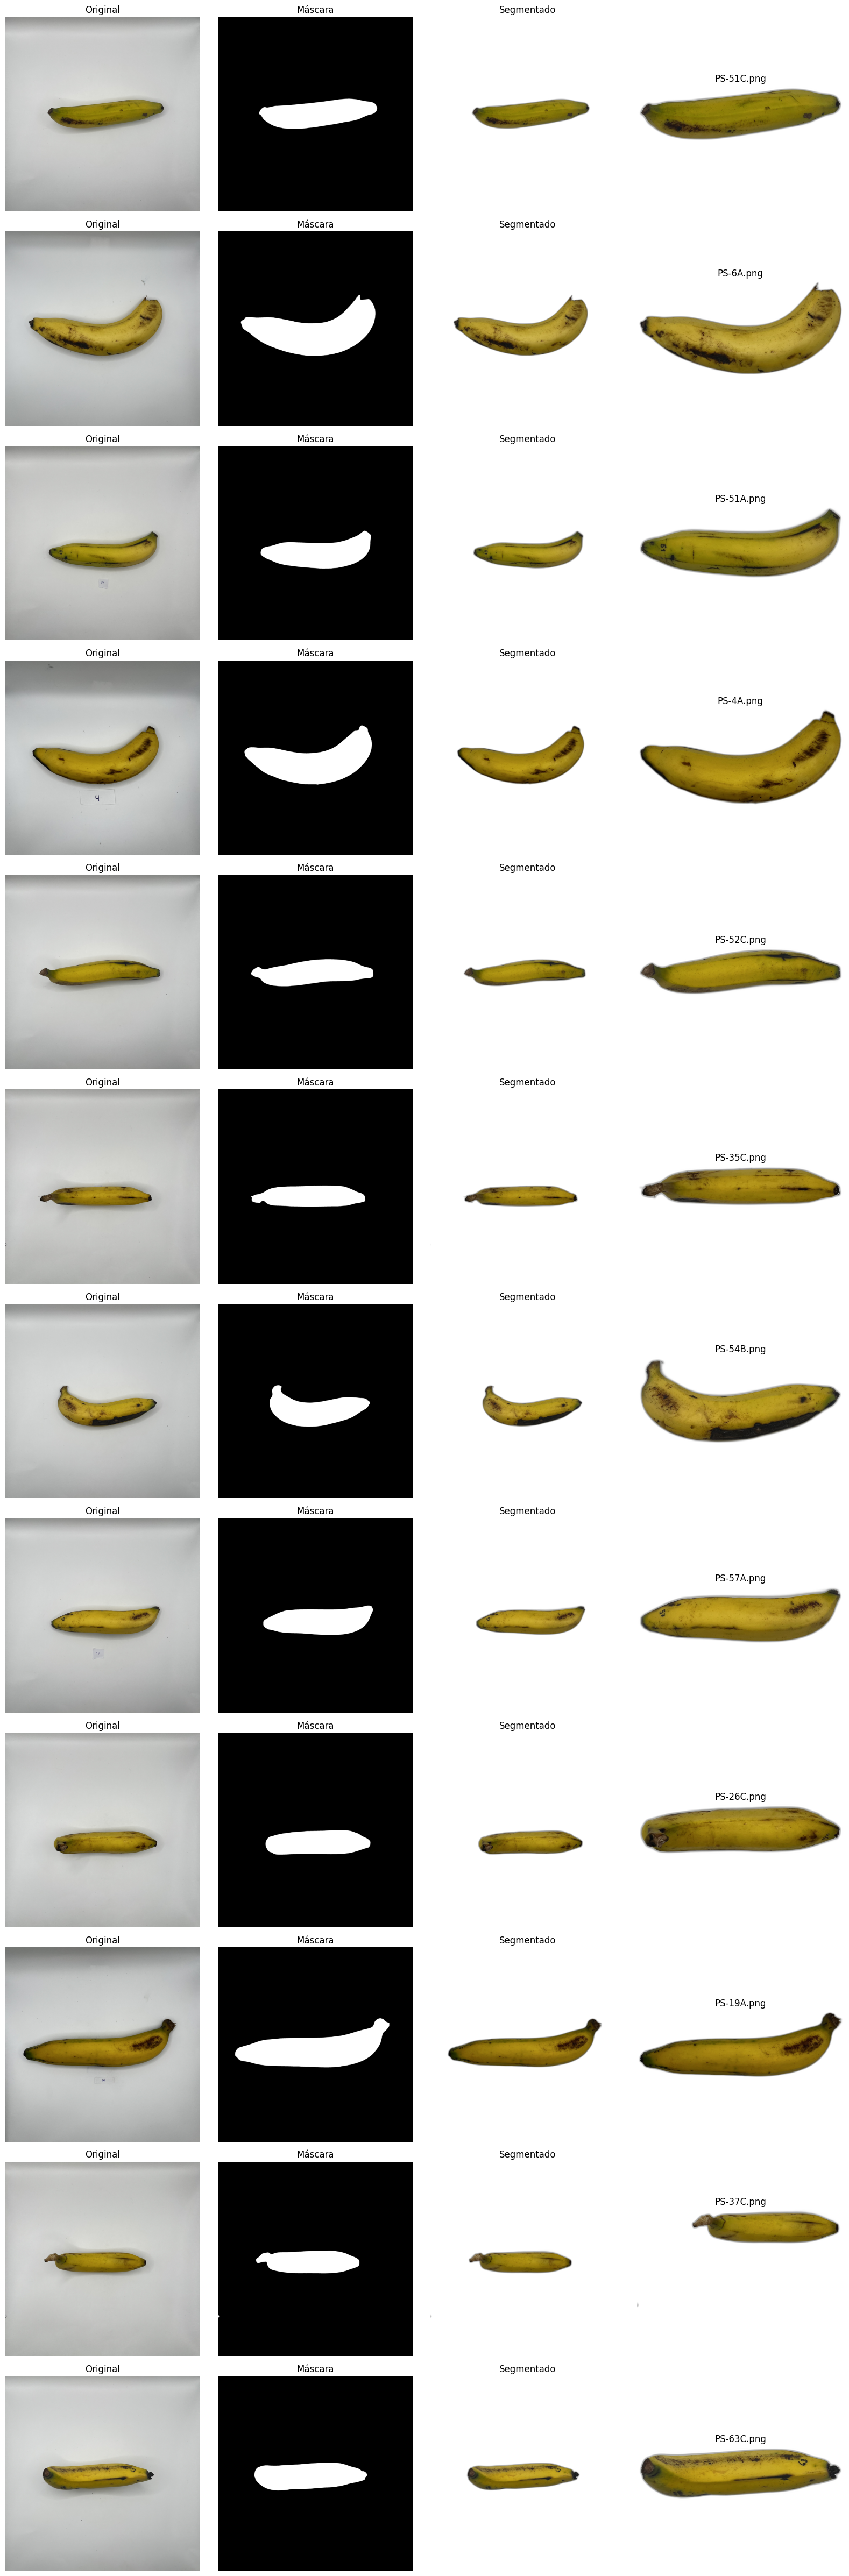

In [ ]:
N = 12

samples = random.sample(converted, N)

fig, ax = plt.subplots(
    N,
    4,
    figsize=(16,4*N)
)

for row, path in enumerate(samples):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    mask, crop, rgba = segment_banana(img)

    ax[row,0].imshow(img)

    ax[row,0].set_title("Original")

    ax[row,1].imshow(mask,cmap="gray")

    ax[row,1].set_title("Máscara")

    ax[row,2].imshow(rgba)

    ax[row,2].set_title("Segmentado")

    ax[row,3].imshow(crop)

    ax[row,3].set_title(os.path.basename(path))

    for i in range(4):

        ax[row,i].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
import cv2
import numpy as np


def extract_color_features(crop):
    """
    Extrae únicamente las variables CIELAB
    sobre los píxeles pertenecientes al plátano.
    """

    rgb = crop[:, :, :3]
    alpha = crop[:, :, 3]

    valid = alpha > 0

    if np.sum(valid) == 0:
        return None

    # Conversión a LAB
    lab = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2LAB
    ).astype(np.float32)

    lab_pixels = lab[valid]

    # Conversión OpenCV -> CIE LAB
    L = lab_pixels[:, 0] * (100.0 / 255.0)
    a = lab_pixels[:, 1] - 128.0
    b = lab_pixels[:, 2] - 128.0

    features = {

        "L_Mean": np.mean(L),
        "L_Std": np.std(L),

        "a_Mean": np.mean(a),
        "a_Std": np.std(a),

        "b_Mean": np.mean(b),
        "b_Std": np.std(b)

    }

    return features

In [ ]:
import gc
import pandas as pd

features = []

for path in tqdm(converted):

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:

        mask, crop, rgba = segment_banana(img)

        if crop is None:
            continue

        feature_dict = extract_color_features(crop)

        if feature_dict is None:
            continue

        feature_dict["Image"] = os.path.basename(path)

        features.append(feature_dict)

    except Exception as e:

        print(f"Error en {os.path.basename(path)}: {e}")

    finally:

        del img

        if "mask" in locals():
            del mask

        if "crop" in locals():
            del crop

        if "rgba" in locals():
            del rgba

        gc.collect()

features = pd.DataFrame(features)

print(features.shape)

features.head()

100%|██████████| 189/189 [18:44<00:00,  5.95s/it]

(189, 7)


,L_Mean,L_Std,a_Mean,a_Std,b_Mean,b_Std,Image
0,36.145451,17.818972,2.385813,3.283869,38.630352,19.407352,PS-18A.png
1,15.905354,10.449408,1.901831,1.972746,11.280392,11.081610,PS-22C.png
2,48.308796,20.543509,-0.843134,1.974719,41.260944,22.460581,PS-63B.png
3,45.357609,19.024017,-2.965358,2.619910,40.732140,21.674900,PS-48B.png
4,43.220745,18.399977,-1.540506,2.291663,39.682144,20.546242,PS-55C.png


In [ ]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
L_Mean,189.0,38.818069,7.409459,15.634012,36.020084,40.793331,43.196739,51.849136
L_Std,189.0,17.815771,2.395075,10.449408,16.494053,18.430010,19.436996,22.228693
a_Mean,189.0,-0.202696,2.542717,-7.652965,-0.846859,0.484374,1.520694,3.531608
a_Std,189.0,2.980496,1.360801,1.680478,2.252557,2.481753,2.975069,8.519168
b_Mean,189.0,36.044731,7.594882,7.595114,34.977699,38.099255,40.274368,45.105991
b_Std,189.0,19.953386,2.649322,10.199379,18.889694,20.364923,21.703857,24.188913


In [ ]:
import re

df = features.copy()

# Extraer número de muestra
df["Sample"] = df["Image"].str.extract(r"(PS-\d+)")

# Promedio de A, B y C
color_features = (

    df.groupby("Sample")[
        [
            "L_Mean",
            "L_Std",
            "a_Mean",
            "a_Std",
            "b_Mean",
            "b_Std"
        ]
    ]

    .mean()

    .reset_index()

)

color_features

,Sample,L_Mean,L_Std,a_Mean,a_Std,b_Mean,b_Std
0,PS-1,44.615437,18.347990,1.148151,2.437612,43.139252,18.639217
1,PS-10,36.184361,14.670926,-6.963781,6.595043,35.310246,18.706400
2,PS-11,37.984425,15.142125,-4.866788,6.836393,36.799633,19.271156
3,PS-12,38.762798,15.191297,-6.462912,6.388748,38.931057,19.139204
4,PS-13,33.339294,16.269491,2.143133,2.920351,35.703400,19.018248
...,...,...,...,...,...,...,...
58,PS-62,46.406597,19.580780,-1.426910,2.386829,39.912174,20.394459
59,PS-63,44.598911,19.575314,-0.297972,2.146924,39.352367,21.576767
60,PS-7,33.248463,13.268199,-6.273068,7.435050,31.936983,17.289171
61,PS-8,34.911930,14.388874,-3.254408,5.837681,33.451260,18.071754


In [ ]:
color_features["Number"] = (

    color_features["Sample"]

    .str.extract(r"(\d+)")

    .astype(int)

)

color_features = color_features.sort_values("Number")

color_features = color_features.drop(columns="Number")

color_features.reset_index(drop=True, inplace=True)

In [ ]:
color_features.to_csv(
    "Colorimetria_LAB.csv",
    index=False
)

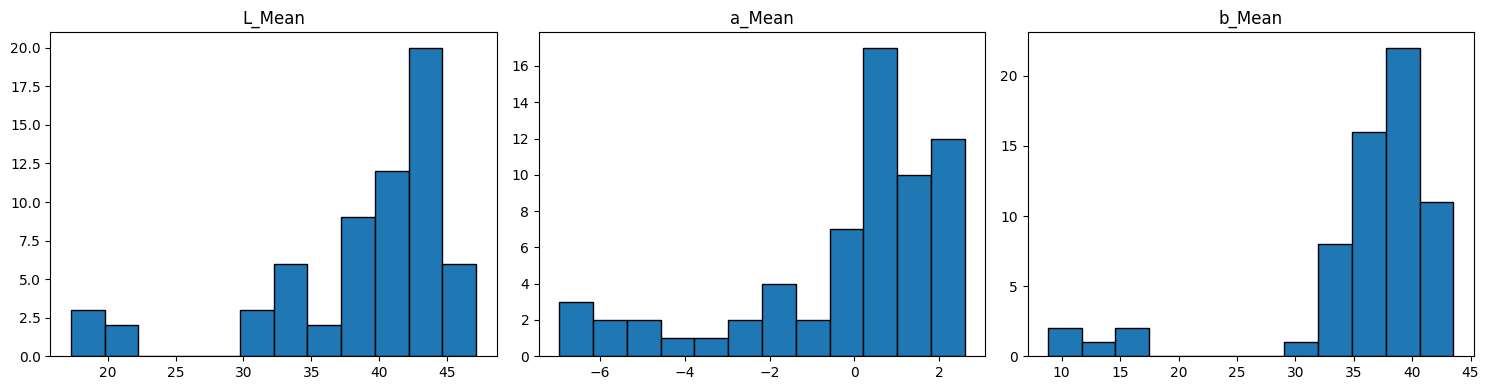

In [ ]:
import matplotlib.pyplot as plt

variables = [
    "L_Mean",
    "a_Mean",
    "b_Mean"
]

plt.figure(figsize=(15,4))

for i,var in enumerate(variables):

    plt.subplot(1,3,i+1)

    plt.hist(
        color_features[var],
        bins=12,
        edgecolor="black"
    )

    plt.title(var)

plt.tight_layout()

plt.show()

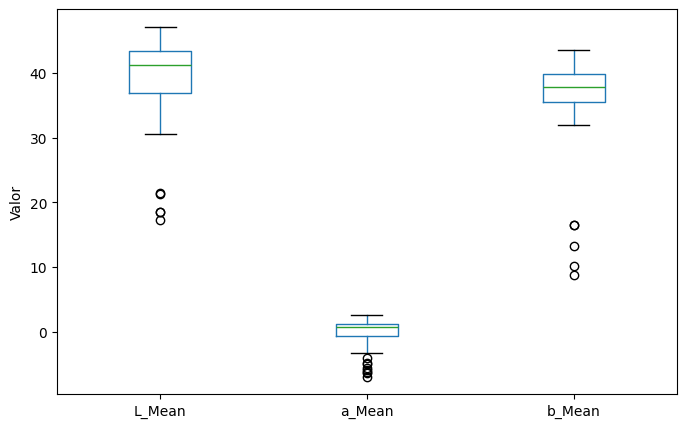

In [ ]:
plt.figure(figsize=(8,5))

color_features[
    [
        "L_Mean",
        "a_Mean",
        "b_Mean"
    ]
].boxplot()

plt.ylabel("Valor")

plt.grid()

plt.show()

In [ ]:
# Extraer el identificador de la muestra (PS-1, PS-2, ...)
features["Sample"] = (
    features["Image"]
    .str.extract(r"(PS-\d+)")
)

# Contar cuántas imágenes tiene cada muestra
conteo = features.groupby("Sample").size()

print(conteo.value_counts())

# Mostrar las muestras que no tengan exactamente 3 imágenes
print(conteo[conteo != 3])

3    63
Name: count, dtype: int64
Series([], dtype: int64)


In [ ]:
color_features.to_csv(
    "Colorimetria_LAB_63.csv",
    index=False
)